# Route 66
This is a map of the places named in the Nat King Cole and Chuck Berry song Route 66. It can give us a sense of which cities were most culturally significant in this period.

Towns with bigger population sizes have been represented with larger dots. Data was taken from the 1950 US census. However, no data had been collected for Winona - a very small town - meaning this has been estimated by dividing the population of its county in 1950 (Coconino county) by 10. This was an arbritary choice, but means the point for Winona is visible on the map.

Towns in the song:<br>
Well, if you ever plan to motor west<br>
Jack, take my way, it's the highway that's the best<br>
Get your kicks on Route 66<br>

Well it winds from **Chicago** to **L.A.** <br>
More than two-thousand miles all the way<br>
Get your kicks on Route 66<br>

Well, it goes from **St. Louis**, **Joplin**, Missouri <br>
**Oklahoma City** looks ooh so pretty <br>
You'll see **Amarillo** and **Gallup**, New Mexico <br>
**Flagstaff**, Arizona, don't forget **Winona** <br>
**Kingsman**, **Barstow**, **San Bernardino** <br>

Won't you get hip on that kindly tip <br>
Jack and take that California trip? <br>
Get your kicks on Route 66 <br>

Well, it goes from **St. Louis**, **Joplin**, Missouri <br>
**Oklahoma City** looks, ooh, so pretty <br>
You'll see **Amarillo**, **Gallup**, New Mexico <br>
**Flagstaff**, Arizona, don't forget **Winona** <br>
**Kingsman**, **Barstow**, **San Bernardino** <br>

Won't you get hip on that kindly tip <br>
Jack and take that California trip? <br>
Get your kicks on Route 66 <br>

Get your kicks on Route 66 <br>
Get your kicks on Route 66 <br> 
Get your kicks on Route 66

Let's manually create a dataset containing the cities listed in the song, their latitudes and their longitudes.

In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import pandas as pd

# dataset of cities and population sizes
data = {"city":["Chicago","L.A.","St. Louis","Joplin", "Oklahoma City", "Amarillo", "Gallup", "Flagstaff", "Winona", "Kingsman", "Barstow", "San Bernardino"],
       "latitude":[41.864951371481055, 34.0962670530509, 38.655179367913625, 37.07898540235688, 35.49240953364765, 35.19886030208132, 35.521631100151815, 35.20132528620923, 35.20437302414543, 35.211891029663576, 34.8751862535193, 34.124263927874594],
       "longitude":[-87.61933052491747, -118.28408561602494, -90.22646601365103, -94.50177137421815, -97.54518121343506, -101.83061605275282, -108.73931417041793, -111.63638374575793, -111.40511972258619, -113.99956698056121, -117.07946180592441, -117.29518288210404],
       "population":[3620962,4046000,1407000,38515,278000,73935,9143,6733,23755*0.1,3314,6130,62798]} # in 1950, no data for Winona

df = pd.DataFrame(data)
df

,city,latitude,longitude,population
0,Chicago,41.864951,-87.619331,3620962.0
1,L.A.,34.096267,-118.284086,4046000.0
2,St. Louis,38.655179,-90.226466,1407000.0
3,Joplin,37.078985,-94.501771,38515.0
4,Oklahoma City,35.492410,-97.545181,278000.0
5,Amarillo,35.198860,-101.830616,73935.0
6,Gallup,35.521631,-108.739314,9143.0
7,Flagstaff,35.201325,-111.636384,6733.0
8,Winona,35.204373,-111.405120,2375.5
9,Kingsman,35.211891,-113.999567,3314.0


Now let's plot this data against a map of the US. The Mercator projection has been used to make the map more visually appealing.

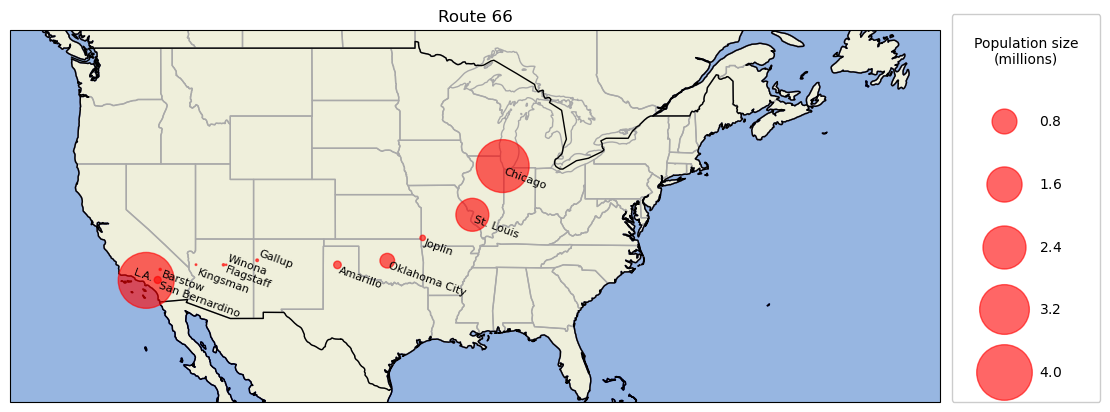

In [2]:
# plot map of US
mapProjection = ccrs.Mercator(min_latitude=20, max_latitude=55)
dataTransform = ccrs.PlateCarree()

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(1, 1, 1, projection=mapProjection)
ax.set_extent([-130, -50, 25, 50], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, edgecolor="white")
ax.add_feature(cfeature.OCEAN, edgecolor="navy")
ax.add_feature(cfeature.STATES, edgecolor="darkgrey")
ax.add_feature(cfeature.BORDERS, edgecolor="black")
ax.add_feature(cfeature.COASTLINE, edgecolor="black")

# plot cities
m = ax.scatter(x=df.longitude, y=df.latitude, color="red", s=df.population/2500, alpha=0.6, zorder=3, transform=dataTransform)

# add labels to cities
for _, row in df.iterrows():
    if row.city == "Winona":
        ax.text(row.longitude, row.latitude-0.9, row.city, transform=dataTransform, fontsize=8, rotation=-20, ha="left", va="bottom", zorder=4)
    elif row.city == "Gallup":
         ax.text(row.longitude, row.latitude-0.7, row.city, transform=dataTransform, fontsize=8, rotation=-20, ha="left", va="bottom", zorder=4)
    elif row.city == "Kingsman":
        ax.text(row.longitude, row.latitude-0.2, row.city, transform=dataTransform, fontsize=8, rotation=-20, ha="left", va="top", zorder=4)
    elif row.city == "L.A.":
        ax.text(row.longitude-1.2, row.latitude+0.9, row.city, transform=dataTransform, fontsize=8, rotation=-20, ha="left", va="top", zorder=4)
    else:
        ax.text(row.longitude, row.latitude, row.city, transform=dataTransform, fontsize=8, rotation=-20, ha="left", va="top", zorder=4)

# add scale to graph
l1 = ax.legend(*m.legend_elements(prop="sizes", num=6, func=lambda x: x*2500, color="red"),
               title="Population size\n(millions)", framealpha=1, loc="lower right",
               bbox_to_anchor=(1.18, -0.02), labelspacing=3.5, handletextpad=1.5, borderpad=1.6)
l1.get_title().set_ha("center")

ax.set_title("Route 66")
plt.show()

## Discussion

It seems that Chicago, St. Louis, and Los Angeles were the most populated cities along this route. This makes sense, since these cities were also culturally signficant for other reasons like their music scenes or for Hollywood [11, 12]. Also, as an important holiday hotspot, L.A. attracted a large amount of traffic from Route 66 [14].

In the middle of Route 66, we see that the towns became much more sparsely populated than at the ends of the route. Many locations could have been considered transit stops along the route. It is noteworthy, however, that Oklahoma City was a moderatelty large settlement in the middle of the route, having rapidly grown in population during the early 20th century, transforming from an agricultural settlement to a commercial centre [13, 15]. This meant it was also an important stop on the route.

## Conclusion

With major population centres at either end of the route, Route 66 was a significant passage by which commerce, culture and tourists could move across the country. Even with many minor towns along its path, Route 66 inspired much culture, and may be remembered for a long time.

## Sources
1. https://genius.com/Chuck-berry-route-66-lyrics
2. https://physics.bu.edu/~redner/projects/population/cities/chicago.html
3. https://www.macrotrends.net/global-metrics/cities/23052/los-angeles/population#google_vignette
4. https://www.macrotrends.net/global-metrics/cities/23152/st-louis/population
5. https://www.macrotrends.net/global-metrics/cities/23088/oklahoma-city/population
6. https://www2.census.gov/library/publications/decennial/1950/pc-02/pc-2-44.pdf p4
7. https://www2.census.gov/library/publications/decennial/1950/pc-03/pc-3-09.pdf
8. https://www2.census.gov/library/publications/decennial/1950/pc-02/pc-2-45.pdf
9. https://www2.census.gov/library/publications/decennial/1950/pc-02/pc-2-16.pdf
10. https://www2.census.gov/library/publications/decennial/1950/pc-03/pc-3-08.pdf
11. https://www.britannica.com/topic/rock-Chicago-1950s-overview-1371220
12. https://www.britannica.com/topic/rock-Los-Angeles-1950s-overview-1371230
13. https://www.okhistory.org/publications/enc/entry?entry=OK025
14. https://www.fhwa.dot.gov/candc/factsheets/route66.pdf#:~:text=In%20the%201950s%2C%20Route%2066%20became%20the,to%20service%20the%20needs%20of%20passing%20motorists
15. https://www.okc.gov/Community-Recreation/Route-66/History-of-Route-66-and-Oklahoma-City